In [1]:
import pandas as pd

dfs = {
    "java": pd.read_csv(
        "../benchmark/final/java_dataset_metadata.csv",
        low_memory=False,
        keep_default_na=False,
    ),
    "python": pd.read_csv(
        "../benchmark/final/py_dataset_metadata.csv",
        low_memory=False,
        keep_default_na=False,
    ),
}

In [2]:
def summarize_data(df: pd.DataFrame):
    df = df[df["validation"]]
    cmt_per_lib = (
        df.groupby("library")["commit"]
        .nunique()
        .reset_index()
        .sort_values("commit", ascending=False)
    )
    instance_per_lib = df["library"].value_counts().reset_index()
    mapping_per_lib = (
        df[["library", "old_api", "new_api"]]
        .drop_duplicates()["library"]
        .value_counts()
        .reset_index()
    )
    instance_per_mapping = (
        df.groupby(["library", "old_api", "new_api"])
        .size()
        .reset_index(name="instance")
        .sort_values("instance", ascending=False)
    )
    cmt_per_mapping = (
        df.groupby(["library", "old_api", "new_api"])["commit"]
        .nunique()
        .reset_index()
        .sort_values("commit", ascending=False)
    )
    mapping_per_update = (
        df[["library", "commit", "old_version", "new_version", "old_api", "new_api"]]
        .drop_duplicates()
        .groupby(["library", "commit", "old_version", "new_version"])
        .size()
        .reset_index(name="mapping")
        .sort_values("mapping", ascending=False)
    )

    return {
        "instance_per_lib": instance_per_lib,
        "cmt_per_lib": cmt_per_lib,
        "mapping_per_lib": mapping_per_lib,
        "instance_per_mapping": instance_per_mapping,
        "cmt_per_mapping": cmt_per_mapping,
        "mapping_per_update": mapping_per_update,
    }


java_summary = summarize_data(dfs["java"])
python_summary = summarize_data(dfs["python"])

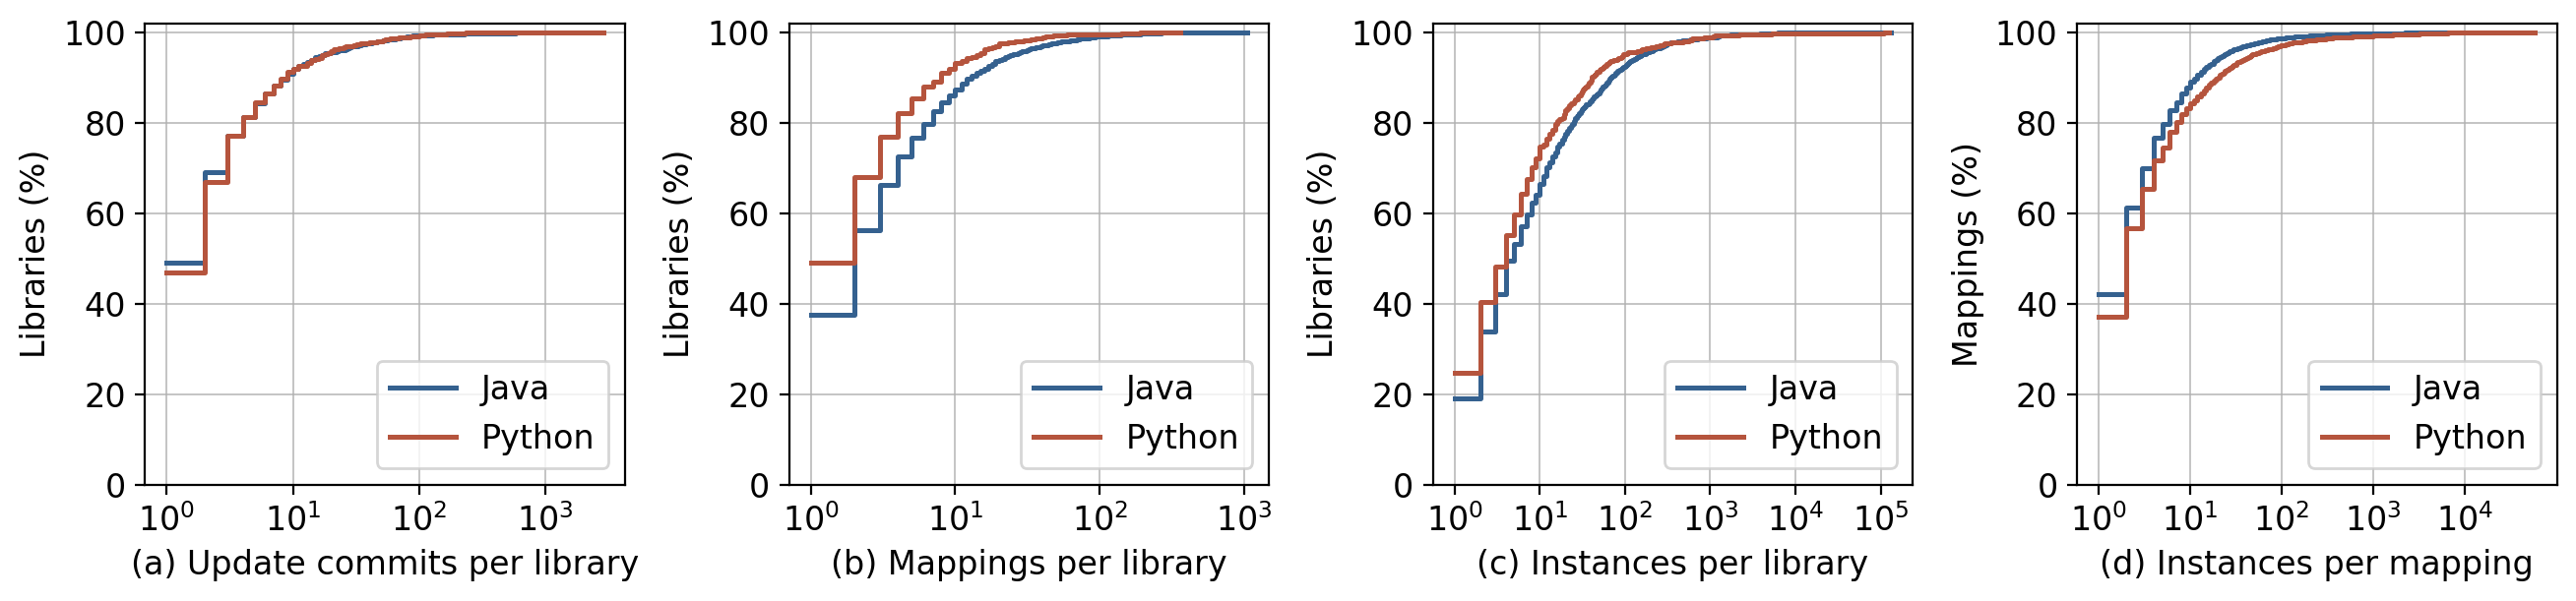

In [3]:
%matplotlib inline
%config InlineBackend.figure_formats="retina"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter, LogLocator

# plt.rcParams.update(
#     {
#         "font.family": "serif",
#         "font.size": 10,
#         "axes.labelsize": 10,
#         "xtick.labelsize": 9,
#         "ytick.labelsize": 9,
#         "legend.fontsize": 9,
#         "pdf.fonttype": 42,
#         "ps.fonttype": 42,
#     }
# )


def compute_cdf(frequencies: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    values = frequencies.dropna().to_numpy()
    values = values[values > 0]

    x, counts = np.unique(values, return_counts=True)
    cdf = np.cumsum(counts) / counts.sum()
    return x, cdf


def plot_cdf(
    summary_data: dict[str, dict[str, pd.Series]],
    labels: dict[str, tuple[str, str]],
    output_path: str | None = None,
) -> None:
    styles = {
        "Java": {"color": "#35618F", "marker": "o"},
        "Python": {"color": "#B5543D", "marker": "s"},
    }

    fig, axs = plt.subplots(1, len(labels), figsize=(3.3 * len(labels), 3.2))

    for ax, (k, label) in zip(axs, labels.items()):
        max_pow = 0
        for language, summary in summary_data.items():
            x, cdf = compute_cdf(summary[k].iloc[:, -1])
            style = styles[language]
            ax.step(
                x,
                cdf,
                where="post",
                label=language,
                color=style["color"],
                linewidth=1.8,
            )
            while 10**max_pow < x[-1]:
                max_pow += 1

        ax.set_xscale("log")
        ax.set_ylim(0, 1.02)
        ax.set_xticks([10**i for i in range(max_pow)])
        ax.minorticks_off()
        ax.tick_params(axis="both", labelsize=12)
        # # ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0,)))
        ax.yaxis.set_major_formatter(PercentFormatter(1.0, symbol=None))
        ax.set_xlabel(label[0], fontsize=12)
        ax.set_ylabel(label[1], fontsize=12)
        ax.grid(True, color="#B0B0B0", linewidth=0.7, alpha=0.75)
        # ax.spines[["top", "right"]].set_visible(False)
        ax.legend(loc="lower right", fontsize=12)

    fig.tight_layout()

    if output_path:
        fig.savefig(output_path, bbox_inches="tight")

    plt.show()


labels = {
    "cmt_per_lib": ("(a) Update commits per library", "Libraries (%)"),
    "mapping_per_lib": ("(b) Mappings per library", "Libraries (%)"),
    "instance_per_lib": ("(c) Instances per library", "Libraries (%)"),
    "instance_per_mapping": ("(d) Instances per mapping", "Mappings (%)"),
    # "cmt_per_mapping": ("The number of commits", "The percentage of mappings"),
    # "mapping_per_update": ("The number of mappings", "The percentage of updates")
}

plot_cdf(
    {"Java": java_summary, "Python": python_summary},
    labels,
    output_path="../submission/figures/rq3_dataset_characteristics.pdf",
)

In [4]:
def cmt_by_lib_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["cmt_per_lib"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} commits")
        print(
            f"    {(frequencies == 1).mean()*100:.1f}% libraries appear in one commit"
        )
        print(
            f"    {(frequencies <= 10).mean()*100:.1f}% libraries appear in at most ten commits"
        )
        print(f"    maxima: {summary['cmt_per_lib'].iloc[0, 0]} in {x[-1]} commits")


cmt_by_lib_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 2.0 commits
    49.0% libraries appear in one commit
    91.9% libraries appear in at most ten commits
    maxima: org.mockito:mockito-core in 1549 commits
Python:
    median: 2.0 commits
    46.9% libraries appear in one commit
    91.9% libraries appear in at most ten commits
    maxima: django in 2867 commits


In [5]:
def mapping_per_lib_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["mapping_per_lib"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} mappings")
        q1 = np.quantile(frequencies, 0.25)
        print(f"    1/4 quantile: {q1} mappings")
        q2 = np.quantile(frequencies, 0.75)
        print(f"    3/4 quantile: {q2} mappings")
        print(f"    {(frequencies == 1).mean()*100:.1f}% libraries have one mapping")
        print(
            f"    {(frequencies <= 10).mean()*100:.1f}% libraries have at most ten mappings"
        )
        print(
            f"    maxima: {summary['mapping_per_lib'].iloc[0, 0]} has {x[-1]} mappings"
        )


mapping_per_lib_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 2.0 mappings
    1/4 quantile: 1.0 mappings
    3/4 quantile: 5.0 mappings
    37.5% libraries have one mapping
    87.4% libraries have at most ten mappings
    maxima: org.elasticsearch:elasticsearch has 1048 mappings
Python:
    median: 2.0 mappings
    1/4 quantile: 1.0 mappings
    3/4 quantile: 3.0 mappings
    49.1% libraries have one mapping
    93.2% libraries have at most ten mappings
    maxima: tensorflow has 361 mappings


In [6]:
def instance_per_lib_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["instance_per_lib"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} instances")
        q1 = np.quantile(frequencies, 0.25)
        print(f"    1/4 quantile: {q1} instances")
        q2 = np.quantile(frequencies, 0.75)
        print(f"    3/4 quantile: {q2} instances")
        print(f"    {(frequencies == 1).mean()*100:.1f}% libraries have one instance")
        print(
            f"    {(frequencies <= 100).mean()*100:.1f}% libraries have at most 100 instances"
        )
        print(
            f"    maxima: {summary['instance_per_lib'].iloc[0, 0]} has {x[-1]} instances"
        )


instance_per_lib_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 5.0 instances
    1/4 quantile: 2.0 instances
    3/4 quantile: 17.0 instances
    19.0% libraries have one instance
    92.6% libraries have at most 100 instances
    maxima: junit:junit has 132630 instances
Python:
    median: 4.0 instances
    1/4 quantile: 2.0 instances
    3/4 quantile: 11.0 instances
    24.6% libraries have one instance
    95.1% libraries have at most 100 instances
    maxima: wagtail has 124226 instances


In [7]:
def instance_per_mapping_analysis(summary_data: dict[str, dict[str, pd.Series]]):
    for language, summary in summary_data.items():
        print(f"{language}:")
        frequencies = summary["instance_per_mapping"].iloc[:, -1]
        x, _ = compute_cdf(frequencies)
        print(f"    median: {np.median(frequencies)} instances")
        q1 = np.quantile(frequencies, 0.25)
        print(f"    1/4 quantile: {q1} instances")
        q2 = np.quantile(frequencies, 0.75)
        print(f"    3/4 quantile: {q2} instances")
        print(f"    {(frequencies == 1).mean()*100:.1f}% mappings have one instance")
        print(
            f"    {(frequencies <= 10).mean()*100:.1f}% mappings have at most 10 instances"
        )
        print(
            f"    maxima: {summary['instance_per_mapping'].iloc[0, 0]} has {x[-1]} instances"
        )


instance_per_mapping_analysis({"Java": java_summary, "Python": python_summary})

Java:
    median: 2.0 instances
    1/4 quantile: 1.0 instances
    3/4 quantile: 4.0 instances
    42.1% mappings have one instance
    89.0% mappings have at most 10 instances
    maxima: junit:junit has 33678 instances
Python:
    median: 2.0 instances
    1/4 quantile: 1.0 instances
    3/4 quantile: 6.0 instances
    37.1% mappings have one instance
    84.4% mappings have at most 10 instances
    maxima: django has 58780 instances
